In [1]:
!pip install folium contextily geopandas shapely plotly


In [4]:
#Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [5]:
#Memanggil data set lewat gdrive
path = "/content/gdrive/MyDrive/Praktikum-Tugas_MachineLearning/Praktikum11"

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.stats import shapiro

import folium
from folium.plugins import HeatMap

import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

import plotly.express as px


In [6]:
df = pd.read_csv('/content/gdrive/MyDrive/Praktikum-Tugas_MachineLearning/Praktikum11/Data/database.csv')

In [7]:
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [22]:
df.describe()

,Latitude,Longitude,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,cluster,pca1,pca2
count,23412.000000,23412.000000,23412.000000,4461.000000,7097.000000,23412.000000,327.000000,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000,23412.000000,2.341200e+04,2.341200e+04
mean,1.679033,39.639961,70.767911,4.993115,275.364098,5.882531,0.071820,48.944618,44.163532,3.992660,7.662759,1.022784,0.000043,-9.711843e-18,2.974252e-17
std,30.113183,125.511959,122.651898,4.875184,162.141631,0.423066,0.051466,62.943106,32.141486,5.377262,10.430396,0.188545,0.066330,3.106993e+00,1.057335e+00
min,-77.080000,-179.997000,-1.100000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.004505,0.085000,0.000000,-1.000000,-1.822944e+00,-1.100235e+00
25%,-18.653000,-76.349750,14.522500,1.800000,146.000000,5.600000,0.046000,10.000000,24.100000,0.968750,5.300000,0.900000,0.000000,-1.421230e+00,-7.008207e-01
50%,-3.568500,103.982000,33.000000,3.500000,255.000000,5.700000,0.059000,28.000000,36.000000,2.319500,6.700000,1.000000,0.000000,-9.630345e-01,-4.412628e-01
75%,26.190750,145.026250,54.000000,6.300000,384.000000,6.000000,0.075500,66.000000,54.000000,4.724500,8.100000,1.130000,0.000000,-4.233978e-01,3.077916e-01
max,86.005000,179.998000,700.000000,91.295000,934.000000,9.100000,0.410000,821.000000,360.000000,37.874000,99.000000,3.440000,3.000000,1.592972e+01,8.052900e+00


In [26]:
# Cleaning Data
required_cols = ['Latitude','Longitude','Depth','Magnitude']

df = df.dropna(subset=required_cols)

# Hapus baris duplikat
df = df.drop_duplicates()

print("Jumlah data setelah cleaning:", len(df))


Jumlah data setelah cleaning: 23412


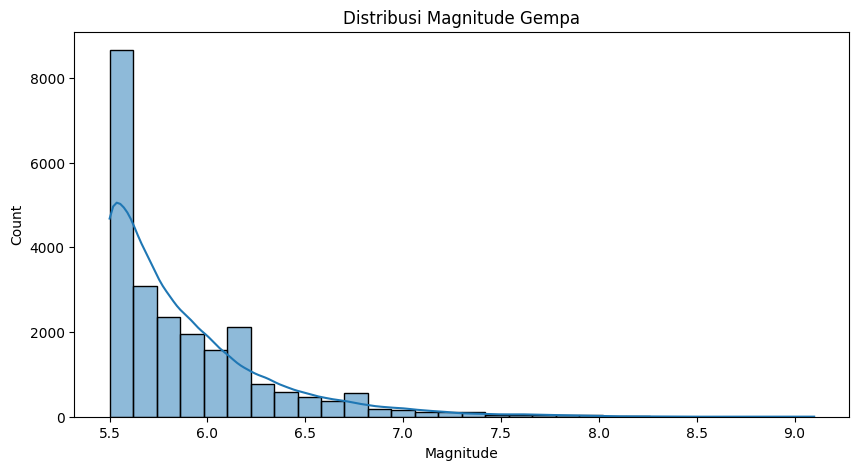

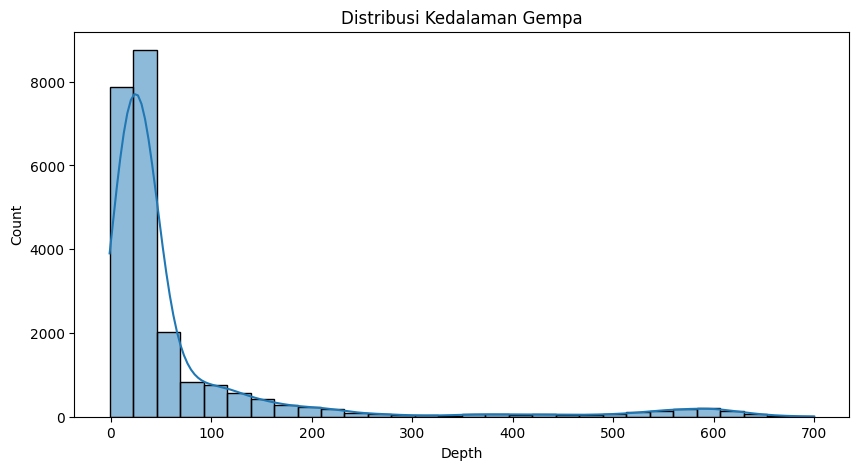

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(df['Magnitude'], kde=True, bins=30)
plt.title("Distribusi Magnitude Gempa")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['Depth'], kde=True, bins=30)
plt.title("Distribusi Kedalaman Gempa")
plt.show()


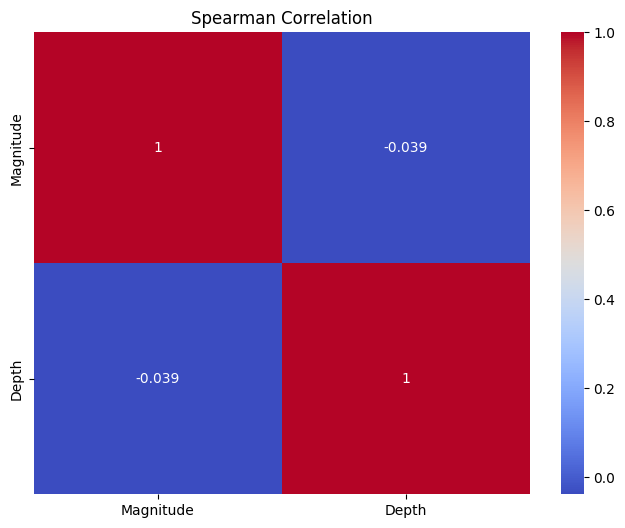

In [28]:
numeric_cols = ['Magnitude','Depth','Total Deaths','Total Injuries']

# buang kolom yang tidak ada
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Spearman Correlation")
plt.show()


In [30]:
for col in numeric_cols:
    stat, p = shapiro(df[col].dropna().sample(500 if len(df)>500 else len(df)))
    print(f"{col} -> p-value = {p}")

print("\nJika p ≤ 0.05 maka data TIDAK normal.")


Magnitude -> p-value = 1.4734454414310028e-22
Depth -> p-value = 6.207119580271946e-35

Jika p ≤ 0.05 maka data TIDAK normal.


In [10]:
m = folium.Map(location=[0, 120], zoom_start=2)

heat_data = df[['Latitude','Longitude']].values.tolist()
HeatMap(heat_data, radius=8).add_to(m)

m


(np.float64(-22040897.38872309),
 np.float64(22041008.70821388),
 np.float64(-15658717.251939904),
 np.float64(23169468.940885883))

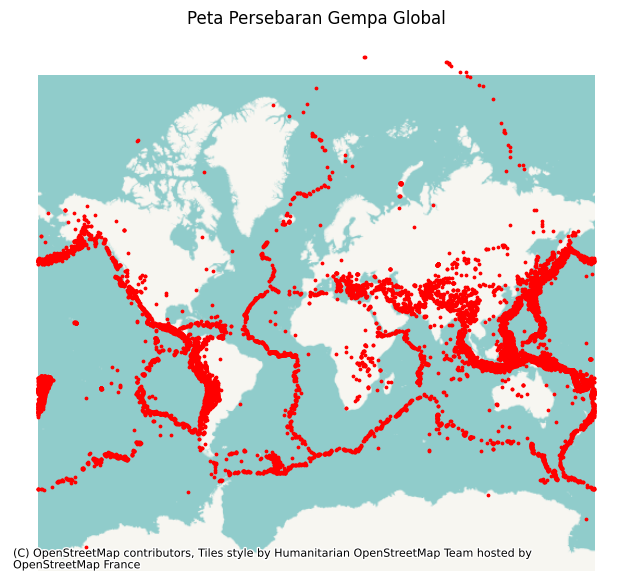

In [31]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.Longitude, df.Latitude),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12,7))
gdf.plot(ax=ax, markersize=3, color='red')

ctx.add_basemap(ax)
ax.set_title("Peta Persebaran Gempa Global")
ax.axis('off')


In [12]:
numeric_cols = ['Magnitude','Depth','Total Deaths','Total Injuries']

# Jika ada kolom yang tidak ada otomatis dibuang
numeric_cols = [col for col in numeric_cols if col in df.columns]

df_numeric = df[numeric_cols].fillna(0)
df_numeric.head()


,Magnitude,Depth
0,6.0,131.6
1,5.8,80.0
2,6.2,20.0
3,5.8,15.0
4,5.8,15.0


In [13]:
scaler = RobustScaler()
scaled = scaler.fit_transform(df_numeric)

scaled_df = pd.DataFrame(scaled, columns=numeric_cols)
scaled_df.head()


,Magnitude,Depth
0,0.75,2.497625
1,0.25,1.190552
2,1.25,-0.329302
3,0.25,-0.455956
4,0.25,-0.455956


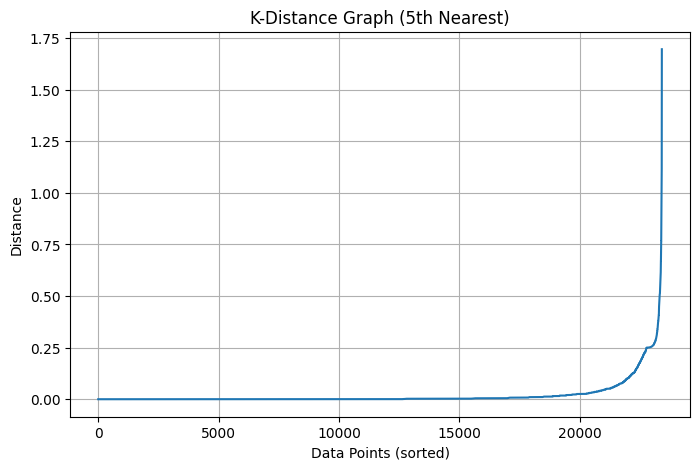

In [14]:
neighbors = 5
nbrs = NearestNeighbors(n_neighbors=neighbors).fit(scaled_df)
distances, _ = nbrs.kneighbors(scaled_df)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-Distance Graph (5th Nearest)")
plt.xlabel("Data Points (sorted)")
plt.ylabel("Distance")
plt.grid(True)
plt.show()


In [34]:
eps_value = 0.28

db = DBSCAN(eps=eps_value, min_samples=5).fit(scaled_df)

df['cluster'] = db.labels_
df['cluster'].value_counts()


,count
cluster,
0,23178
-1,175
1,9
2,9
5,9
4,6
3,6
6,6
9,5


In [16]:
mask = df['cluster'] != -1

score = silhouette_score(scaled_df[mask], df['cluster'][mask])
print("Silhouette Score:", score)


Silhouette Score: 0.6592461287798149


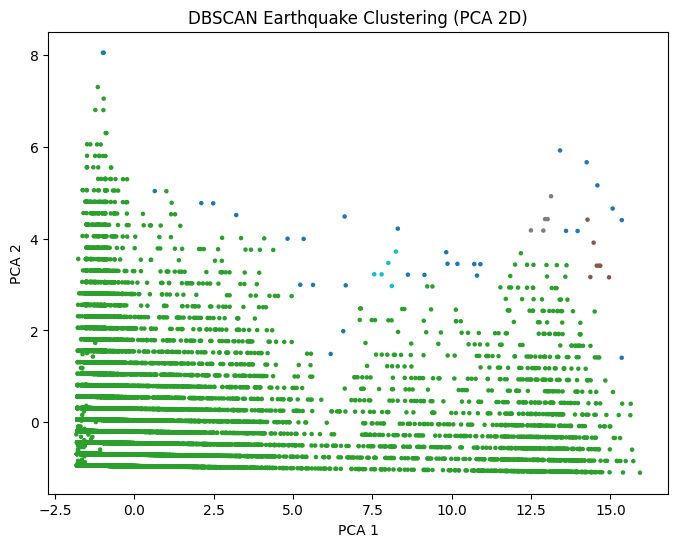

In [17]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

df['pca1'] = pca_data[:,0]
df['pca2'] = pca_data[:,1]

plt.figure(figsize=(8,6))
plt.scatter(df['pca1'], df['pca2'], c=df['cluster'], cmap='tab10', s=5)
plt.title("DBSCAN Earthquake Clustering (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [19]:
fig = px.scatter(
    df,
    x='pca1',
    y='pca2',
    color='cluster',
    hover_data=['Magnitude','Depth','Latitude','Longitude'],
    title="DBSCAN Earthquakes – Interactive Visualization"
)

fig.show()

In [20]:
summary = df.groupby('cluster')[numeric_cols].mean()
summary


,Magnitude,Depth
cluster,,
-1,7.551613,397.280968
0,5.879195,69.987354
1,7.357143,644.500000
2,7.700000,578.200000
3,7.240000,383.120000
